In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import pandas as pd

# Deep learning frameworks

# Visualization

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer
from src.preprocessing.log_scale import LogTransformer

# Local imports - models and evaluation
from src.models.dummy import RepeatLastValuesConfig, LitRepeatLastValues

from src.models.tft import TFTConfig, LitTFT
from src.models.ealstm import EALSTMConfig, LitEALSTM
from src.models.tide import TiDEConfig, LitTiDE
from src.models.tsmixer import TSMixerConfig, LitTSMixer
from src.model_evaluation.evaluators import TSForecastEvaluator
from src.model_evaluation.visualization import (
    plot_basin_map,
    plot_metric_boxplot,
    plot_rolling_forecast,
    plot_basin_difference_map
)
from src.model_evaluation.hp_from_yaml import hp_from_yaml

---

In [3]:
STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "temperature_2m_mean",
    "total_precipitation_sum",
]

TARGET = "streamflow"

In [4]:
ealstm_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/yaml_files/ealstm.yaml"
tft_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/yaml_files/tft.yaml"
tide_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/yaml_files/tide.yaml"
tsmixer_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/yaml_files/tsmixer.yaml"

tft_hp = hp_from_yaml("tft", tft_yaml)
tide_hp = hp_from_yaml("tide", tide_yaml)
ealstm_hp = hp_from_yaml("ealstm", ealstm_yaml)
tsmixer_hp = hp_from_yaml("tsmixer", tsmixer_yaml)

In [5]:
TFT_config = TFTConfig(**tft_hp)
EALSTM_config = EALSTMConfig(**ealstm_hp)
TiDE_config = TiDEConfig(**tide_hp)
TSMixer_config = TSMixerConfig(**tsmixer_hp)

dummy_config = RepeatLastValuesConfig(
    input_len=tide_hp["input_len"],
    input_size=tide_hp["input_size"],
    output_len=tide_hp["output_len"],
)


---

In [6]:
# Either Kyrgyzstan or Tajikistan or combined
COUNTRY = "Tajikistan"

In [7]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[
    ts_columns + ["date"] + ["gauge_id"]
]
ca_static_data = ca_caravan.get_static_attributes()[static_columns + ["country"]]

Found 78 total CA basins


In [8]:
# ids for the COUUNTRY

country_ids = ca_static_data[ca_static_data["country"] == COUNTRY]["gauge_id"].unique()

ca_ts_data = ca_ts_data[ca_ts_data["gauge_id"].isin(country_ids)]
ca_static_data = ca_static_data[ca_static_data["gauge_id"].isin(country_ids)]

print(f"Found {len(country_ids)} total CA basins in {COUNTRY}")

Found 16 total CA basins in Tajikistan


---

In [9]:
# Use GroupedTransformer for both features and target
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline(
        [("log", LogTransformer()), ("scaler", StandardScaleTransformer())]
    ),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)


static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])
preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [10]:
STATIC_FEATURES = [col for col in static_columns]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

tft_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tft_hp["input_len"],
    output_length=tft_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

ealstm_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=ealstm_hp["input_len"],
    output_length=ealstm_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tide_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tide_hp["input_len"],
    output_length=tide_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tsmixer_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tsmixer_hp["input_len"],
    output_length=tsmixer_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

In [11]:
tft_qm_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/quantile_mapped/tft/run_0/last.ckpt"
ealstm_qm_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/quantile_mapped/ealstm/run_0/last.ckpt"
tide_qm_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/quantile_mapped/tide/run_0/last.ckpt"
tsmixer_qm_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/quantile_mapped/tsmixer/run_0/last.ckpt"

tft_original_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/original/tft/run_0/last.ckpt"
ealstm_original_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/original/ealstm/run_0/last.ckpt"
tide_original_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/original/tide/run_0/last.ckpt"
tsmixer_original_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/QuantileMapping/results/checkpoints/original/tsmixer/run_0/last.ckpt"

In [12]:
dummy_model = LitRepeatLastValues(config=dummy_config)  
tft_qm = LitTFT.load_from_checkpoint(tft_qm_ckpt, config=TFT_config)
ealstm_qm = LitEALSTM.load_from_checkpoint(ealstm_qm_ckpt, config=EALSTM_config)
tide_qm = LitTiDE.load_from_checkpoint(tide_qm_ckpt, config=TiDE_config)
tsmixer_qm = LitTSMixer.load_from_checkpoint(tsmixer_qm_ckpt, config=TSMixer_config)

tft_original = LitTFT.load_from_checkpoint(tft_original_ckpt, config=TFT_config)
ealstm_original = LitEALSTM.load_from_checkpoint(ealstm_original_ckpt, config=EALSTM_config)
tide_original = LitTiDE.load_from_checkpoint(tide_original_ckpt, config=TiDE_config)
tsmixer_original = LitTSMixer.load_from_checkpoint(tsmixer_original_ckpt, config=TSMixer_config)

# Create a dictionary mapping model names to (model, datamodule) tuples
models_and_datamodules = {
    "dummy": (dummy_model, tide_data_module),
    "tft_qm": (tft_qm, tft_data_module),
    "ealstm_qm": (ealstm_qm, ealstm_data_module),
    "tide_qm": (tide_qm, tide_data_module),
    "tsmixer_qm": (tsmixer_qm, tsmixer_data_module),
    "tft_original": (tft_original, tft_data_module),
    "ealstm_original": (ealstm_original, ealstm_data_module),
    "tide_original": (tide_original, tide_data_module),
    "tsmixer_original": (tsmixer_original, tsmixer_data_module),
}


evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,
    trainer_kwargs={"accelerator": "gpu", "devices": 1},
)

/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1, which is newer than your current Lightning version: v2.5.0.post0


In [13]:
# Run evaluation
results = evaluator.test_models()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing dummy...
Original basins: 16
Retained basins: 16
Domain CA (source): Created 30759 valid sequences from 16 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.0739368200302124
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(30759, 10), obs=(30759, 10), basin_ids=(30759,)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.04968612641096115
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(30759, 10), obs=(30759, 10), basin_ids=(30759,)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing tsmixer_original...
Original basins: 16
Retained basins: 16
Domain CA (source): Created 30935 valid sequences from 16 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.04956119507551193
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(30935, 10), obs=(30935, 10), basin_ids=(30935,)


In [14]:
def filter_growing_season(eval_results):
    """
    Filter evaluation results to include only data from the growing season (April to October).
    
    Args:
        eval_results: Dictionary containing evaluation results with a 'df' key
        
    Returns:
        Dictionary with filtered dataframe and original metrics
    """
    # Create a copy of the results to avoid modifying the original
    filtered_results = eval_results.copy()
    
    # Extract the dataframe
    df = eval_results['df'].copy()
    
    # Ensure date column is datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Filter for growing season (April to October)
    growing_season_df = df[(df['date'].dt.month >= 4) & (df['date'].dt.month < 10)]
    
    # Replace the dataframe in the results
    filtered_results['df'] = growing_season_df
    
    return filtered_results


seasonal_tide_original_results = filter_growing_season(results["tide_original"])
seasonal_tide_qm_results = filter_growing_season(results["tide_qm"])
seasonal_ealstm_original_results = filter_growing_season(results["ealstm_original"])
seasonal_ealstm_qm_results = filter_growing_season(results["ealstm_qm"])
seasonal_tsmixer_original_results = filter_growing_season(results["tsmixer_original"])
seasonal_tsmixer_qm_results = filter_growing_season(results["tsmixer_qm"])
seasonal_tft_original_results = filter_growing_season(results["tft_original"])
seasonal_tft_qm_results = filter_growing_season(results["tft_qm"])
    

seasonal_tide_original_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tide_original_results["df"])
seasonal_tide_qm_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tide_qm_results["df"])
seasonal_ealstm_original_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_ealstm_original_results["df"])
seasonal_ealstm_qm_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_ealstm_qm_results["df"])
seasonal_tsmixer_original_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tsmixer_original_results["df"])
seasonal_tsmixer_qm_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tsmixer_qm_results["df"])
seasonal_tft_original_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tft_original_results["df"])
seasonal_tft_qm_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tft_qm_results["df"])

seasonal_tide_original_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tide_original_results["df"])
seasonal_tide_qm_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tide_qm_results["df"])
seasonal_ealstm_original_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_ealstm_original_results["df"])
seasonal_ealstm_qm_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_ealstm_qm_results["df"])
seasonal_tsmixer_original_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tsmixer_original_results["df"])
seasonal_tsmixer_qm_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tsmixer_qm_results["df"])
seasonal_tft_original_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tft_original_results["df"])
seasonal_tft_qm_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tft_qm_results["df"])

seasonal_results = {}

seasonal_results["tide_original"] = seasonal_tide_original_results
seasonal_results["tide_qm"] = seasonal_tide_qm_results
seasonal_results["ealstm_original"] = seasonal_ealstm_original_results
seasonal_results["ealstm_qm"] = seasonal_ealstm_qm_results
seasonal_results["tsmixer_original"] = seasonal_tsmixer_original_results
seasonal_results["tsmixer_qm"] = seasonal_tsmixer_qm_results
seasonal_results["tft_original"] = seasonal_tft_original_results
seasonal_results["tft_qm"] = seasonal_tft_qm_results

In [15]:
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgb


def generate_color_pairs(
    num_pairs: int,
    base_palette: Optional[str] = "husl",
    lightness_factor: float = 0.4,
) -> List[str]:
    # Get base colors from seaborn
    base_colors = sns.color_palette(base_palette, n_colors=num_pairs)

    # Create lighter versions of each color
    light_colors = []
    for rgb in base_colors:
        # Convert to brighter version by moving toward white
        light_rgb = tuple(c + (1 - c) * lightness_factor for c in rgb)
        light_colors.append(light_rgb)

    # Interleave dark and light variants to create pairs
    color_pairs = []
    for dark, light in zip(base_colors, light_colors):
        color_pairs.extend([dark, light])

    return color_pairs

In [16]:
sns.reset_defaults()

/Users/cooper/Desktop/CAMELS-CH/src/model_evaluation/visualization.py:181: UserWarning: The palette list has more values (16) than needed (8), which may not be intended.
  sns.boxplot(
/Users/cooper/Desktop/CAMELS-CH/src/model_evaluation/visualization.py:187: UserWarning: The palette list has more values (16) than needed (8), which may not be intended.
  sns.stripplot(


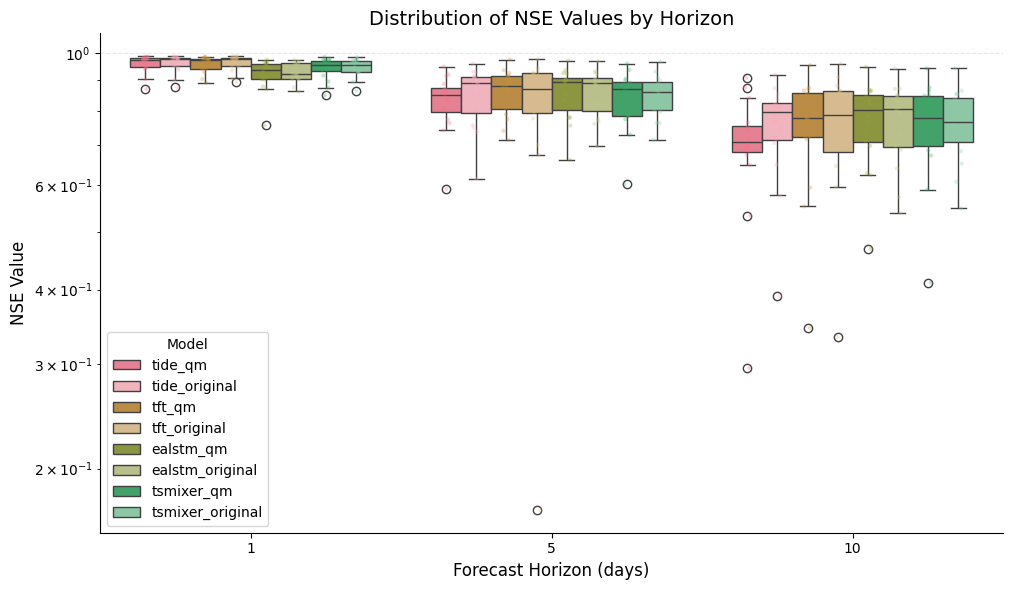

In [20]:
palette = generate_color_pairs(8)


fig, ax = plot_metric_boxplot(
    seasonal_results,
    ["tide_qm", "tide_original", "tft_qm", "tft_original", "ealstm_qm", "ealstm_original", "tsmixer_qm", "tsmixer_original"],
    metric='NSE',
    individual_points=True,
    palette=palette,
    horizons=[1, 5, 10],
    fig_size=(10, 6),
)

# # Set log scale for y-axis
ax.set_yscale('log')


In [18]:
plt.show()

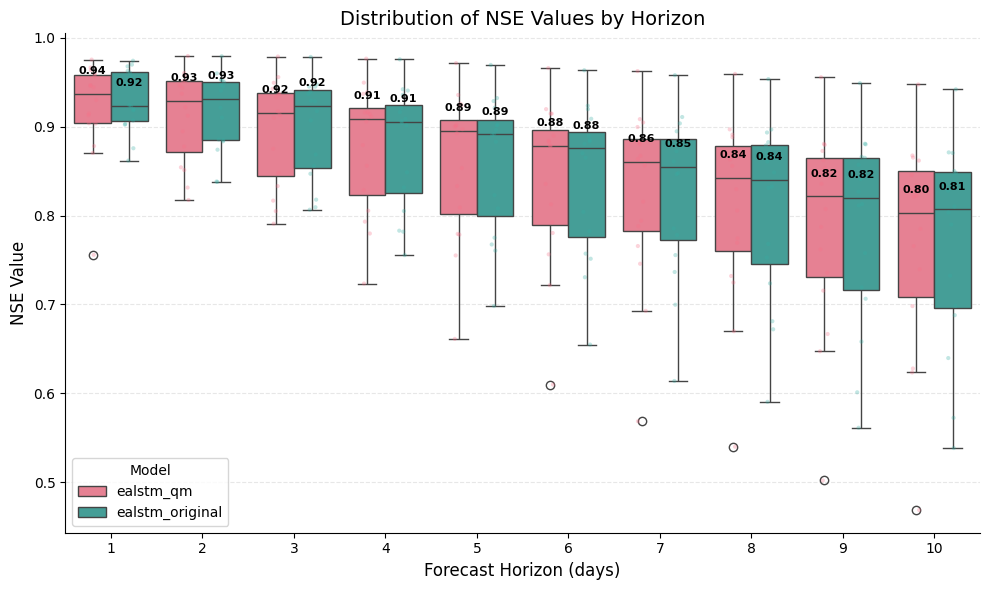

In [21]:
fig, ax = plot_metric_boxplot(
    seasonal_results,
    ["ealstm_qm", "ealstm_original"],
    metric='NSE',
    individual_points=True,
    fig_size=(10, 6),
)

plt.show()

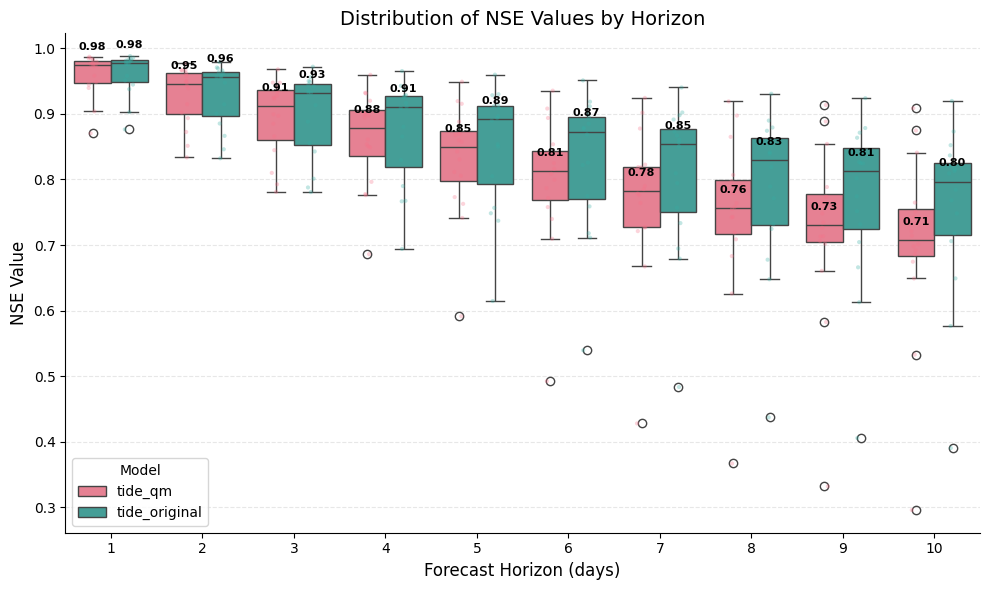

In [22]:
fig, ax = plot_metric_boxplot(
    seasonal_results,
    ["tide_qm", "tide_original"],
    metric='NSE',
    individual_points=True,
    fig_size=(10, 6),
)

plt.show()

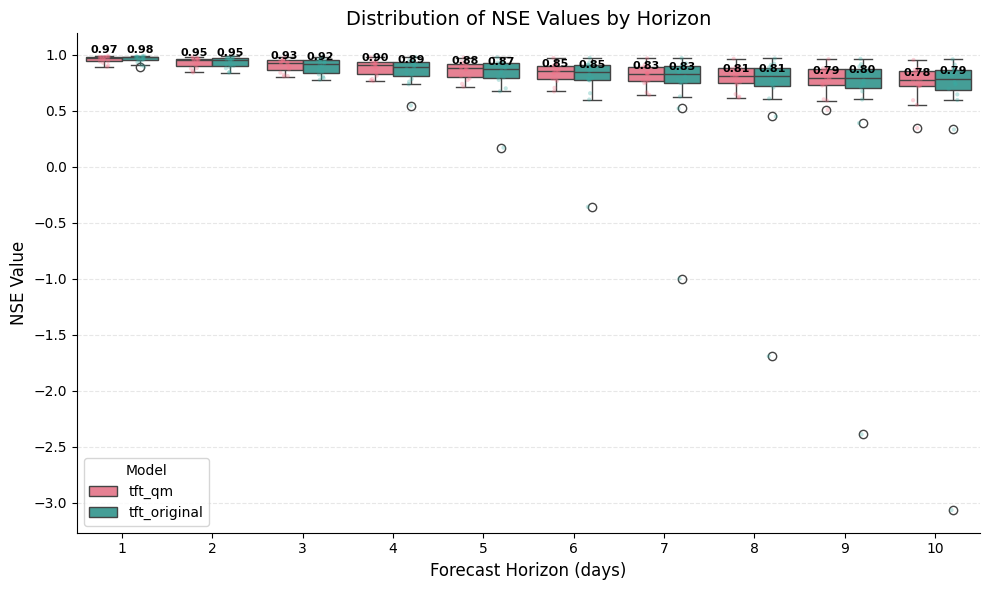

In [23]:
fig, ax = plot_metric_boxplot(
    seasonal_results,
    ["tft_qm", "tft_original"],
    metric='NSE',
    individual_points=True,
    fig_size=(10, 6),
)

plt.show()

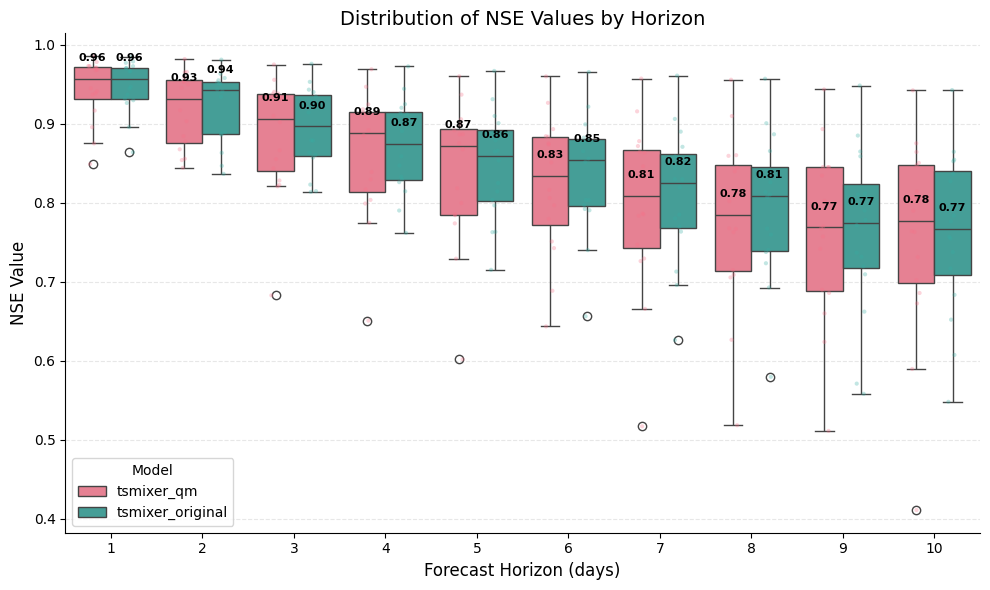

In [24]:
fig, ax = plot_metric_boxplot(
    seasonal_results,
    ["tsmixer_qm", "tsmixer_original"],
    metric='NSE',
    individual_points=True,
    fig_size=(10, 6),
)

plt.show()

In [25]:
tide_qm_summary = evaluator.summarize_metrics(seasonal_results["tide_qm"]["metrics"])
tide_original_summary = evaluator.summarize_metrics(seasonal_results["tide_original"]["metrics"])
ealstm_qm_summary = evaluator.summarize_metrics(seasonal_results["ealstm_qm"]["metrics"])
ealstm_original_summary = evaluator.summarize_metrics(seasonal_results["ealstm_original"]["metrics"])
tsmixer_qm_summary = evaluator.summarize_metrics(seasonal_results["tsmixer_qm"]["metrics"])
tsmixer_original_summary = evaluator.summarize_metrics(seasonal_results["tsmixer_original"]["metrics"])
tft_qm_summary = evaluator.summarize_metrics(seasonal_results["tft_qm"]["metrics"])
tft_original_summary = evaluator.summarize_metrics(seasonal_results["tft_original"]["metrics"])

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_summary(
    summary_df1: pd.DataFrame, 
    summary_df2: pd.DataFrame, 
    metric: str, 
    label1: str = 'Dataset 1', 
    label2: str = 'Dataset 2', 
    per_basin: bool = False, 
    figsize=(10, 6)
):
    """
    Plot comparison of metric summaries between two models/datasets.
    
    Args:
        summary_df1: Metric summary dataframe for first model
        summary_df2: Metric summary dataframe for second model
        metric: Name of the metric to plot (e.g., 'NSE', 'RMSE')
        label1: Label for first model/dataset
        label2: Label for second model/dataset
        per_basin: Whether to plot per-basin metrics
        figsize: Figure size as tuple (width, height)
    """
    plt.figure(figsize=figsize)

    if per_basin:
        # Unstack both dataframes
        df_plot1 = summary_df1[metric].unstack(level=0)
        df_plot2 = summary_df2[metric].unstack(level=0)

        # Combine dataframes with a new column for dataset
        combined_df = pd.concat([
            df_plot1.melt(ignore_index=False).assign(dataset=label1),
            df_plot2.melt(ignore_index=False).assign(dataset=label2)
        ])

        # Create grouped bar plot
        ax = sns.barplot(
            data=combined_df.reset_index(),
            x="horizon",
            y="value",
            hue="dataset",
            palette=sns.color_palette("husl", 2),
            dodge=True
        )
        plt.title(f"{metric} by Dataset, Basin, and Horizon")
        
    else:
        # Prepare data for side-by-side plotting
        data = pd.DataFrame({
            'Horizon': summary_df1.index,
            f'{label1}': summary_df1[metric],
            f'{label2}': summary_df2[metric]
        })

        # Melt the dataframe for seaborn
        melted_data = data.melt(id_vars='Horizon', var_name='Dataset', value_name='Value')

        # Create side-by-side bar plot
        ax = sns.barplot(
            x='Horizon', 
            y='Value', 
            hue='Dataset', 
            data=melted_data,
            palette=sns.color_palette("husl", 2),
            dodge=True
        )

        plt.title(f"{metric} Comparison")

        # Add value labels
        for i, dataset in enumerate([label1, label2]):
            for j, v in enumerate(data[f'{dataset}']):
                x_offset = -0.2 if i == 0 else 0.2
                plt.text(j + x_offset, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    # Move legend below the plot
    plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
    
    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Enhance the axes
    plt.xlabel("Forecast Horizon")
    plt.ylabel(metric)
    
    # Adjust y-axis limits to leave room for labels
    y_min, y_max = plt.ylim()
    plt.ylim(y_min, y_max * 1.05)
    
    plt.tight_layout()
    sns.despine()
    plt.show()

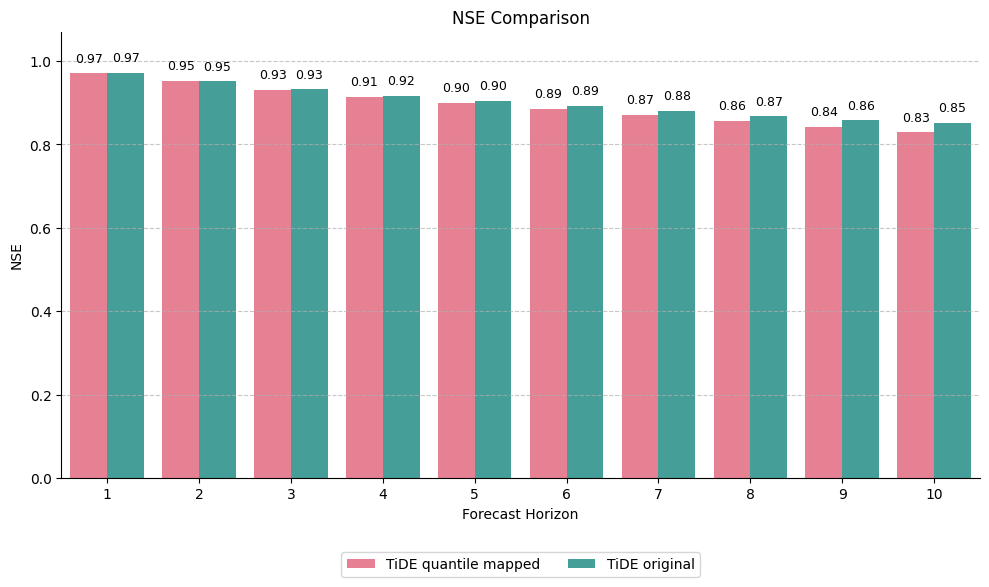

In [28]:
# Example usage:
plot_metric_summary(
    summary_df1=tide_qm_summary, 
    summary_df2=tide_original_summary, 
    metric="NSE", 
    label1="TiDE quantile mapped",
    label2="TiDE original",
    per_basin=False
)

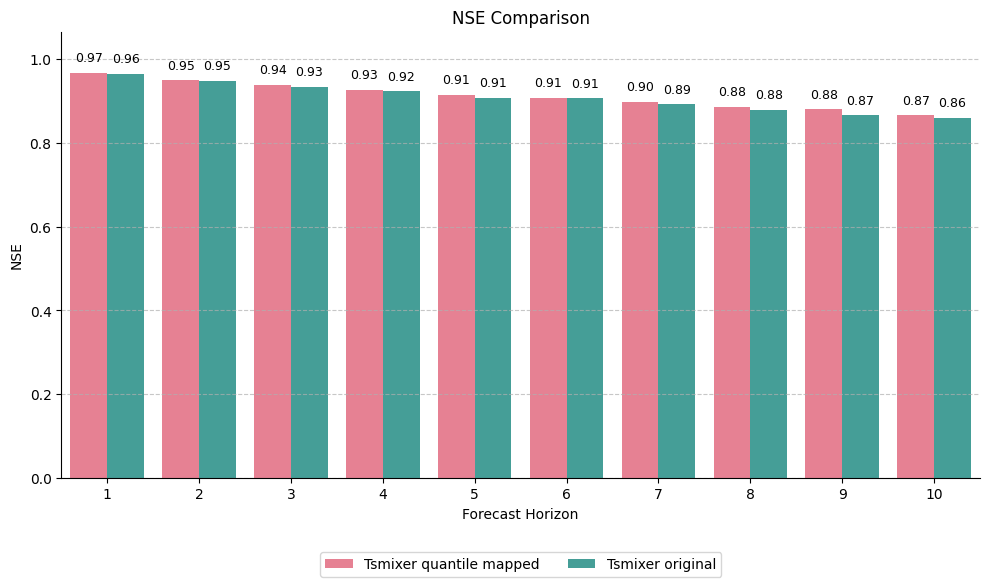

In [29]:
# Example usage:
plot_metric_summary(
    summary_df1=tsmixer_qm_summary, 
    summary_df2=tsmixer_original_summary, 
    metric="NSE", 
    label1="Tsmixer quantile mapped",
    label2="Tsmixer original",
    per_basin=False
)

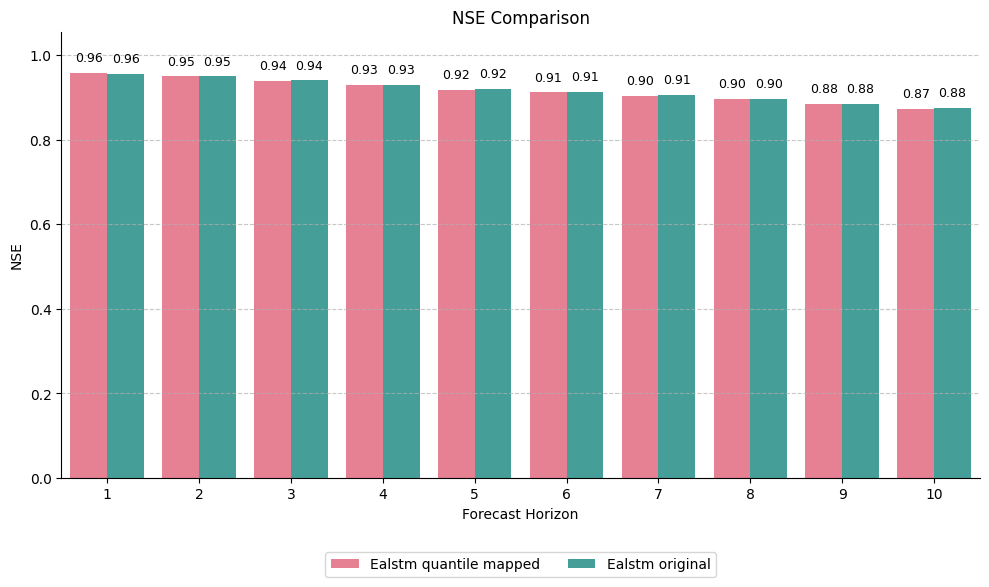

In [30]:
# Example usage:
plot_metric_summary(
    summary_df1=ealstm_qm_summary, 
    summary_df2=ealstm_original_summary, 
    metric="NSE", 
    label1="Ealstm quantile mapped",
    label2="Ealstm original",
    per_basin=False
)

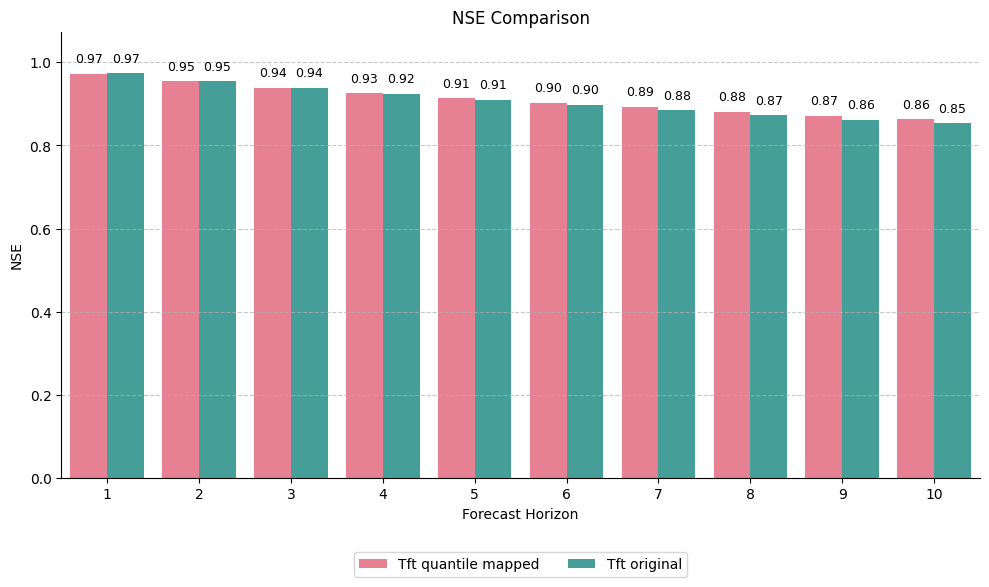

In [31]:
# Example usage:
plot_metric_summary(
    summary_df1=tft_qm_summary, 
    summary_df2=tft_original_summary, 
    metric="NSE", 
    label1="Tft quantile mapped",
    label2="Tft original",
    per_basin=False
)

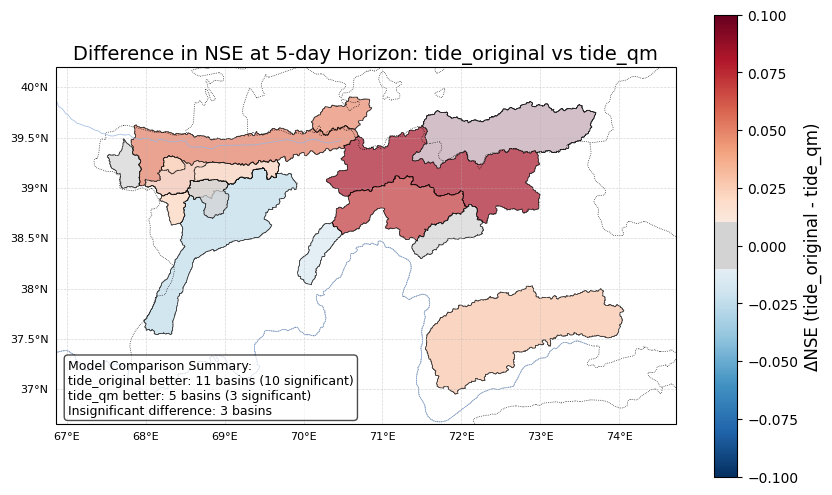

In [37]:
fig, ax = plot_basin_difference_map(
    seasonal_results,
    "tide_qm",
    "tide_original",
    caravanify_instance=ca_caravan,
    hist_in_legend=False,
    horizon=5,
    vmax=0.1,
    vmin=-0.1,
    fig_size=(10, 6),
    threshold=0.01
)

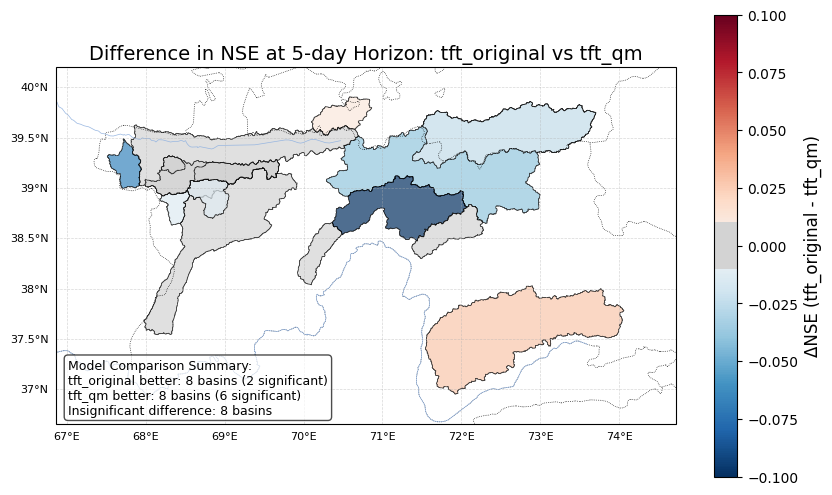

In [38]:
fig, ax = plot_basin_difference_map(
    seasonal_results,
    "tft_qm",
    "tft_original",
    caravanify_instance=ca_caravan,
    hist_in_legend=False,
    horizon=5,
    vmax=0.1,
    vmin=-0.1,
    fig_size=(10, 6),
    threshold=0.01
)

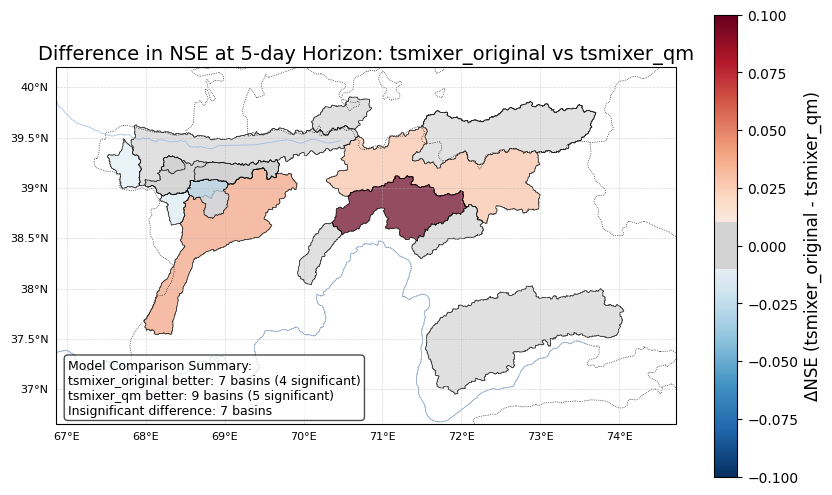

In [39]:
fig, ax = plot_basin_difference_map(
    seasonal_results,
    "tsmixer_qm",
    "tsmixer_original",
    caravanify_instance=ca_caravan,
    hist_in_legend=False,
    horizon=5,
    vmax=0.1,
    vmin=-0.1,
    fig_size=(10, 6),
    threshold=0.01
)

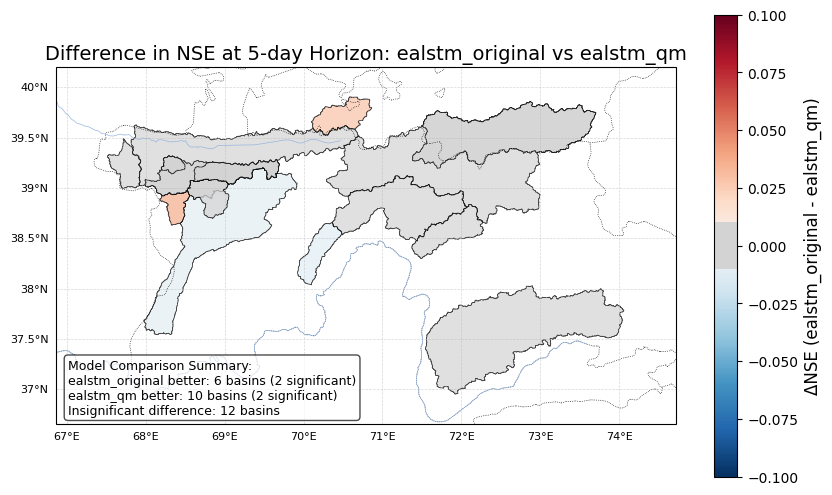

In [40]:
fig, ax = plot_basin_difference_map(
    seasonal_results,
    "ealstm_qm",
    "ealstm_original",
    caravanify_instance=ca_caravan,
    hist_in_legend=False,
    horizon=5,
    vmax=0.1,
    vmin=-0.1,
    fig_size=(10, 6),
    threshold=0.01
)